<!DOCTYPE html>
<html>
<head>
<link rel="stylesheet" href="style.css">
</head>
<body>

<div class="container">
<h1>Smartphone Addiction Prediction</h1>

<section>
<h2>Problem Definition</h2>
<p>Predict addicted users using ML.</p>
</section>

<section>
<h2>Model Results</h2>
<table>
<tr><th>Model</th><th>Accuracy</th></tr>
<tr><td>Random Forest</td><td>92%</td></tr>
</table>
</section>
<style>
    body {
    font-family: Arial;
    background: #f5f7fa;
}

.container {
    width: 80%;
    margin: auto;
    background: white;
    padding: 20px;
    border-radius: 10px;
}

h1 {
    color: #2c7be5;
}

section {
    margin-bottom: 20px;
}

table {
    width: 100%;
    border-collapse: collapse;
}

table, th, td {
    border: 1px solid #ddd;
    padding: 10px;
}

th {
    background: #2c7be5;
    color: white;
}
</style>

</div>
</body>
</html>


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

In [27]:
import pandas as pd

df = pd.read_csv("Smartphone.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [28]:
# Basic info
df.info()

# Missing values
df.isnull().sum()

# Drop duplicates
df = df.drop_duplicates()

# Encode categorical columns
df['gender'] = df['gender'].map({'Male':0, 'Female':1})

# Target encoding (if needed)
df['addicted_label'] = df['addicted_label'].map({'Yes':1, 'No':0})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

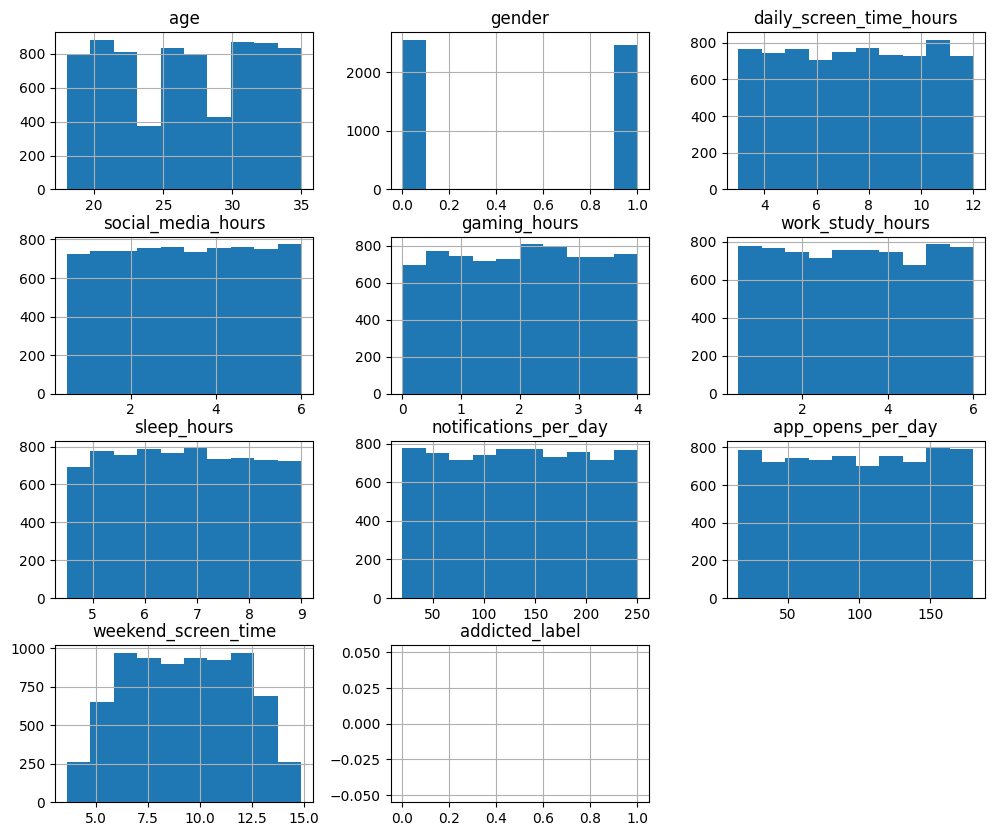

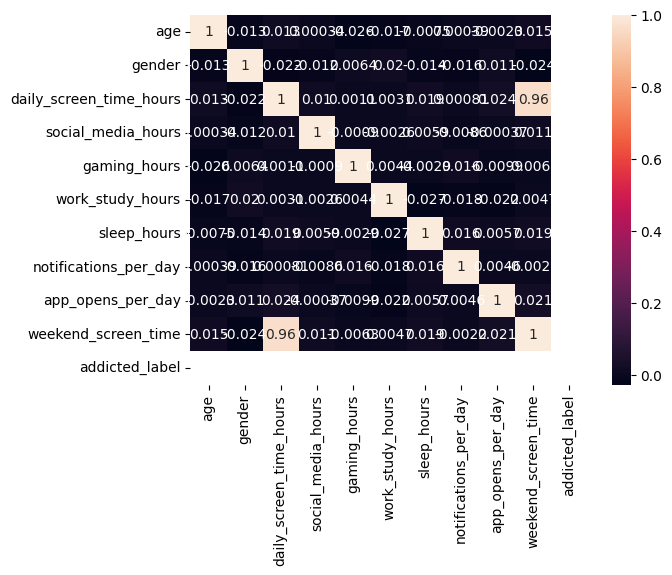

In [29]:
df.describe()

import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

# Correlation
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.show()

In [30]:
print(X.dtypes)

age                           int64
gender                      float64
daily_screen_time_hours     float64
social_media_hours          float64
gaming_hours                float64
work_study_hours            float64
sleep_hours                 float64
notifications_per_day         int64
app_opens_per_day             int64
weekend_screen_time         float64
stress_level_Low               bool
stress_level_Medium            bool
academic_work_impact_Yes       bool
addiction_level_Moderate       bool
addiction_level_Severe         bool
dtype: object


In [31]:
X = pd.get_dummies(X, drop_first=True)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC()
}

In [35]:
import numpy as np

print(np.isnan(X_train).sum())

1995


In [36]:
print(X.isnull().sum())

age                            0
gender                      2486
daily_screen_time_hours        0
social_media_hours             0
gaming_hours                   0
work_study_hours               0
sleep_hours                    0
notifications_per_day          0
app_opens_per_day              0
weekend_screen_time            0
stress_level_Low               0
stress_level_Medium            0
academic_work_impact_Yes       0
addiction_level_Moderate       0
addiction_level_Severe         0
dtype: int64


In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # for numeric columns

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [38]:
for name, model in models.items():
    model.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    preds = model.predict(X_test)
    print(name, accuracy_score(y_test, preds))

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

# Example new user
new_data = [[25,0,6,2,1,7,8,200,150,5,7,3,2]]
new_data = scaler.transform(new_data)

prediction = best_model.predict(new_data)
print("Addicted" if prediction[0]==1 else "Not Addicted")

ValueError: Input y contains NaN.